# 02 — Baseline
### Tugas Mandiri Hari 1 · Python untuk Sistem Cerdas · Project: ProjectMatch AI

| Keterangan | Isi |
|---|---|
| Nama Mahasiswa | Khoirulbarie Kholifatul Anshori |
| NIM | V3925028 |
| Kelas / Angkatan | TI B / 2025 |
| Project / Tim | ProjectMatch AI |
| Dataset | `Resume.csv` (2.484 CV, 24 kategori bidang) |

Notebook ini mencakup **Soal 3** (pembersihan data dan feature engineering), **Soal 4** (baseline project), dan **Soal 5** (pemeriksaan data leakage). Rumusan masalah dan EDA ada di `01_eda.ipynb`.

Ringkasan rumusan (dari Soal 1): input adalah teks CV, output adalah peringkat 24 bidang proyek. Kategori pada dataset dipakai sebagai proksi bidang proyek yang benar. Metrik utama: **Recall@3 dan MRR**, dilengkapi Recall@1, Recall@5, dan Macro Recall@1.

## Setup

In [1]:
from pathlib import Path
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

CANDIDATES = [Path('../data/raw/Resume.csv'), Path('data/raw/Resume.csv'), Path('Resume.csv')]
DATA_PATH = next((p for p in CANDIDATES if p.exists()), None)
assert DATA_PATH is not None, 'Resume.csv tidak ditemukan. Taruh di data/raw/ lalu jalankan ulang.'

# Resume_html tidak dibaca: isinya versi HTML dari teks yang sama (lihat 01_eda.ipynb)
df_mentah = pd.read_csv(DATA_PATH, usecols=['ID', 'Resume_str', 'Category'])
print('Ukuran data mentah:', df_mentah.shape)

Ukuran data mentah: (2484, 3)


---
## Soal 3 — Pembersihan Data dan Feature Engineering

Jenis data project ini adalah **teks**, sehingga pembersihan mengikuti poin (c) di soal: huruf kecil, normalisasi kata tidak baku, lalu representasi TF-IDF. Ditambah penanganan duplikat dan CV kosong dari temuan EDA, serta *masking* data pribadi.

### 3a. Data Cleaning

In [2]:
df_bersih = df_mentah.copy()
n_awal = len(df_bersih)

# 1) Hapus CV duplikat berdasarkan isi teks (ID berbeda tidak berarti orang berbeda)
df_bersih = df_bersih.drop_duplicates(subset='Resume_str')
print('Duplikat dihapus   :', n_awal - len(df_bersih))

# 2) Buang CV yang kosong (hanya spasi)
kosong = df_bersih['Resume_str'].str.strip().str.len() == 0
print('CV kosong dibuang  :', kosong.sum())
df_bersih = df_bersih[~kosong].reset_index(drop=True)

print('Ukuran sesudah     :', df_bersih.shape)

Duplikat dihapus   : 2
CV kosong dibuang  : 1
Ukuran sesudah     : (2481, 3)


In [3]:
# 3) Fungsi pembersihan teks
NORMALISASI = {                      # kata tidak baku / singkatan -> bentuk baku
    r'c\+\+'           : ' cplusplus ',
    r'\bc#'            : ' csharp ',
    r'\bnode\.js\b'    : ' nodejs ',
    r'\.net\b'         : ' dotnet ',
    r'\bms office\b'   : ' microsoft office ',
    r'\bmgmt\b'        : ' management ',
    r'\bdept\b'        : ' department ',
    r'\ba/r\b'         : ' accounts receivable ',
    r'\ba/p\b'         : ' accounts payable ',
    r'\bsr\.'          : ' senior ',
    r'\bjr\.'          : ' junior ',
}

def bersihkan_teks(t):
    t = t.lower()
    t = re.sub(r'https?://\S+|www\.\S+', ' ', t)                 # masking URL
    t = re.sub(r'\S+@\S+\.\S+', ' ', t)                           # masking email
    t = re.sub(r'\(?\d{3}\)?[-.\s]\d{3}[-.\s]\d{4}', ' ', t)      # masking telepon
    t = t.replace('\xa0', ' ').replace('\uff0d', ' ')             # spasi non-breaking, tanda hubung lebar
    t = re.sub(r'company name', ' ', t)                           # placeholder boilerplate
    t = re.sub(r'city\s*,\s*state', ' ', t)
    for pola, ganti in NORMALISASI.items():
        t = re.sub(pola, ganti, t)
    t = re.sub(r'[^a-z]+', ' ', t)                                # sisakan huruf saja
    return re.sub(r'\s+', ' ', t).strip()

# 4) Pisahkan judul/header CV (sebelum bagian pertama seperti "Summary"/"Skills") dari isi CV.
#    Dipakai untuk uji sensitivitas leakage di Soal 5.
BAGIAN = (r'\b(Summary|Professional Summary|Career Overview|Highlights|Skills|Core Qualifications|'
          r'Qualifications|Experience|Professional Experience|Work History|Education|Objective|'
          r'Accomplishments|Profile|Career Focus|Executive Profile)\b')

def pisah_header(t):
    m = re.search(BAGIAN, t)
    return (t[:m.start()], t[m.start():]) if m else ('', t)

pasangan = df_bersih['Resume_str'].apply(pisah_header)
df_bersih['teks_penuh'] = df_bersih['Resume_str'].apply(bersihkan_teks)
df_bersih['teks_tanpa_header'] = pasangan.apply(lambda p: bersihkan_teks(p[1]))
df_bersih['judul_cv'] = pasangan.apply(lambda p: bersihkan_teks(p[0]))

print('Contoh SEBELUM (mentah):')
print(repr(df_mentah.loc[df_mentah['ID'] == df_bersih.loc[0, 'ID'], 'Resume_str'].iloc[0][:350]))
print('\nContoh SESUDAH (teks_penuh):')
print(df_bersih.loc[0, 'teks_penuh'][:350])
print('\nJudul CV terpisah   :', df_bersih.loc[0, 'judul_cv'])

Contoh SEBELUM (mentah):
'         HR ADMINISTRATOR/MARKETING ASSOCIATE\n\nHR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights      '

Contoh SESUDAH (teks_penuh):
hr administrator marketing associate hr administrator summary dedicated customer service manager with years of experience in hospitality and customer service management respected builder and leader of customer focused teams strives to instill a shared enthusiastic commitment to customer service highlights focused on customer satisfaction team manag

Judul CV terpisah   : hr administrator marketing associate hr administrator


In [4]:
# Bukti pembersihan: placeholder, email, URL, dan telepon sudah hilang
cek = {'company name': 'company name', 'city state': r'city\s*,?\s*state', 'tanda @': '@', 'http/www': r'http|www\.'}
mentah_ada = df_mentah['Resume_str'].str.lower()
print(f'{"pola":<14}{"sebelum":>10}{"sesudah":>10}')
for nama, p in cek.items():
    a = mentah_ada.str.contains(p, regex=True).sum()
    b = df_bersih['teks_penuh'].str.contains(p, regex=True).sum()
    print(f'{nama:<14}{a:>10}{b:>10}')

df_bersih['n_kata_mentah'] = df_bersih['Resume_str'].str.split().str.len()
df_bersih['n_kata_bersih'] = df_bersih['teks_penuh'].str.split().str.len()
print('\nMedian jumlah kata  : mentah =', int(df_bersih['n_kata_mentah'].median()),
      '| bersih =', int(df_bersih['n_kata_bersih'].median()))

pola             sebelum   sesudah
company name        2483         0
city state          2362         2
tanda @               33         0


http/www             109        28



Median jumlah kata  : mentah = 757 | bersih = 716


**Catatan hasil pembersihan.** Placeholder "Company Name" dan tanda `@` (email) sudah hilang sepenuhnya; nomor telepon ikut hilang karena masking diikuti pembuangan semua angka. Sisa 28 CV pada baris `http/www` bukan URL, melainkan kata biasa "http" atau "https" yang disebut sebagai istilah teknis (URL asli sudah dimasking). Sisa 2 CV pada `city state` terdiri dari satu varian placeholder tanpa koma dan satu kecocokan palsu ("city statement of work"). Median jumlah kata turun dari 757 menjadi 716 karena angka, tanda baca, dan placeholder dibuang.

### 3b. Feature Engineering (fitur turunan berbasis domain)

Empat fitur turunan dibuat langsung dari teks CV, sehingga tidak memakai informasi dari label:

| Fitur | Arti | Alasan secara domain |
|---|---|---|
| `jumlah_kata` | Panjang CV setelah dibersihkan | Proksi seberapa lengkap CV diisi |
| `jumlah_bagian_cv` | Banyaknya bagian baku yang ditemukan (Summary, Skills, Experience, Education, dst.) | CV yang terstruktur lebih mudah dibaca dan dicocokkan |
| `tahun_pengalaman_klaim` | Angka terbesar pada frasa "N years/yrs" yang ditulis kandidat | Tingkat senioritas yang dinyatakan sendiri oleh kandidat |
| `jumlah_skill_teknis` | Banyaknya skill teknis unik dari leksikon (Python, SQL, Excel, AutoCAD, dst.) | Relevan untuk pencocokan skill dengan kebutuhan proyek |

In [5]:
SEKSI = (r'(?<![A-Za-z])(Summary|Professional Summary|Highlights|Skills|Core Qualifications|Qualifications|'
         r'Experience|Professional Experience|Work History|Education|Education and Training|Accomplishments|'
         r'Certifications|Languages|Affiliations|Additional Information|Interests|Objective|'
         r'Career Overview|Profile)\s{3,}')

def tahun_klaim(t):
    angka = [int(x) for x in re.findall(r'(\d{1,2})\s*\+?\s*(?:years|yrs)', t.lower())]
    angka = [a for a in angka if 0 < a <= 50]
    return max(angka) if angka else np.nan        # NaN dibiarkan: tidak diisi sebelum split

LEKSIKON_SKILL = ['python', 'java', 'javascript', 'sql', 'html', 'css', 'php', 'cplusplus', 'csharp', 'linux',
                  'windows', 'excel', 'powerpoint', 'oracle', 'aws', 'azure', 'docker', 'git', 'sap', 'tableau',
                  'photoshop', 'illustrator', 'indesign', 'autocad', 'matlab', 'sas', 'spss', 'salesforce',
                  'quickbooks', 'peoplesoft', 'erp', 'crm', 'networking', 'database', 'agile', 'scrum',
                  'microsoft office', 'cpr', 'hipaa', 'osha', 'gaap']

def jumlah_skill(teks_bersih):
    padded = ' ' + teks_bersih + ' '
    return sum((' ' + s + ' ') in padded for s in LEKSIKON_SKILL)

raw = df_bersih['Resume_str']
df_bersih['jumlah_kata'] = df_bersih['n_kata_bersih']
df_bersih['jumlah_bagian_cv'] = raw.apply(lambda t: len(set(re.findall(SEKSI, t))))
df_bersih['tahun_pengalaman_klaim'] = raw.apply(tahun_klaim)
df_bersih['jumlah_skill_teknis'] = df_bersih['teks_penuh'].apply(jumlah_skill)

fitur_baru = ['jumlah_kata', 'jumlah_bagian_cv', 'tahun_pengalaman_klaim', 'jumlah_skill_teknis']
print(df_bersih[fitur_baru].describe().round(2).to_string())
print('\nMissing pada tahun_pengalaman_klaim:', df_bersih['tahun_pengalaman_klaim'].isna().sum(),
      f'({df_bersih["tahun_pengalaman_klaim"].isna().mean():.1%}) -> dibiarkan NaN')
df_bersih[['ID', 'Category'] + fitur_baru].head()

       jumlah_kata  jumlah_bagian_cv  tahun_pengalaman_klaim  jumlah_skill_teknis
count      2481.00           2481.00                  879.00              2481.00
mean        767.86              5.42                   12.67                 2.62
std         363.85              1.27                    8.25                 2.50
min          87.00              1.00                    2.00                 0.00
25%         609.00              5.00                    6.00                 1.00
50%         716.00              5.00                   10.00                 2.00
75%         883.00              6.00                   18.00                 4.00
max        5110.00             11.00                   50.00                17.00

Missing pada tahun_pengalaman_klaim: 1602 (64.6%) -> dibiarkan NaN


,ID,Category,jumlah_kata,jumlah_bagian_cv,tahun_pengalaman_klaim,jumlah_skill_teknis
0,16852973,HR,608,6,15.0,0
1,22323967,HR,664,4,NaN,5
2,33176873,HR,990,5,20.0,3
3,27018550,HR,349,4,20.0,3
4,17812897,HR,1179,5,NaN,3


In [6]:
# Pemeriksaan kewajaran fitur: rata-rata jumlah_skill_teknis per kategori
rata = df_bersih.groupby('Category')['jumlah_skill_teknis'].mean().sort_values(ascending=False).round(2)
print('Lima kategori dengan skill teknis terbanyak:'); print(rata.head(5).to_string())
print('\nLima kategori dengan skill teknis tersedikit:'); print(rata.tail(5).to_string())

Lima kategori dengan skill teknis terbanyak:
Category
INFORMATION-TECHNOLOGY    4.91
CONSULTANT                3.93
ENGINEERING               3.70
ACCOUNTANT                3.54
DESIGNER                  3.51

Lima kategori dengan skill teknis tersedikit:
Category
ARTS       1.97
FITNESS    1.65
SALES      1.63
TEACHER    1.44
CHEF       0.95


### 3c. Representasi TF-IDF (hanya untuk eksplorasi)

TF-IDF di sini dihitung pada **seluruh** data hanya untuk melihat kata penciri tiap bidang, seperti langkah A.12. Representasi ini **tidak** dipakai untuk evaluasi. Pada Soal 4, TF-IDF dibangun ulang di dalam `Pipeline` setelah data dipisah, supaya tidak terjadi kontaminasi data uji.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_eksplorasi = TfidfVectorizer(stop_words='english', min_df=3, max_df=0.8, sublinear_tf=True)
X_eks = tfidf_eksplorasi.fit_transform(df_bersih['teks_penuh'])
print('Ukuran matriks TF-IDF :', X_eks.shape)
print(f'Kepadatan matriks     : {X_eks.nnz / (X_eks.shape[0] * X_eks.shape[1]):.3%} (sisanya nol)')

vocab = tfidf_eksplorasi.get_feature_names_out()
for kat in ['INFORMATION-TECHNOLOGY', 'CHEF', 'HEALTHCARE', 'ACCOUNTANT']:
    idx = np.where(df_bersih['Category'].values == kat)[0]
    rata_bobot = np.asarray(X_eks[idx].mean(axis=0)).ravel()
    top = vocab[rata_bobot.argsort()[::-1][:8]]
    print(f'{kat:<24}: {", ".join(top)}')

Ukuran matriks TF-IDF : (2481, 14381)
Kepadatan matriks     : 2.035% (sisanya nol)
INFORMATION-TECHNOLOGY  : technology, network, hardware, server, information, systems, software, security
CHEF                    : chef, food, kitchen, culinary, menu, restaurant, cooking, sous
HEALTHCARE              : healthcare, patient, medical, care, patients, health, clinical, nursing
ACCOUNTANT              : accountant, accounting, accounts, financial, ledger, tax, payable, statements


**Alasan setiap keputusan pembersihan dan fitur baru:**
- *Hapus duplikat berdasarkan teks, bukan ID.* EDA menunjukkan 2 pasang CV bersisi sama persis dengan ID berbeda. Jika dibiarkan, satu salinan bisa jatuh ke data latih dan salinan lainnya ke data uji sehingga skor tampak lebih baik dari sebenarnya.
- *Buang CV kosong.* CV tanpa teks menghasilkan vektor nol, sehingga tidak bisa dicocokkan dengan bidang mana pun dan hanya mengganggu evaluasi.
- *Huruf kecil dan hanya huruf.* Menyamakan "Sales", "SALES", dan "sales" menjadi satu token. Angka dan tanda baca dibuang karena tidak membawa makna bidang dan hanya memperbesar kosakata.
- *Masking email, URL, telepon.* Alasannya privasi (Soal 1g) sekaligus kualitas: token seperti alamat email unik per orang dan tidak berguna untuk mencocokkan bidang.
- *Hapus placeholder "Company Name" dan "City , State".* EDA menunjukkan keduanya adalah kata paling dominan di korpus padahal tidak membawa informasi bidang.
- *Normalisasi kata tidak baku* (`C++` menjadi `cplusplus`, `A/R` menjadi `accounts receivable`, dst.). Tanpa ini, tokenisasi default memecah atau menghilangkan simbol dan membuang makna skill tersebut.
- *Pisahkan judul CV dari isi.* Judul CV berisi nama jabatan yang sangat dekat dengan label bidang. Pemisahan ini memungkinkan uji sensitivitas di Soal 5.
- *`tahun_pengalaman_klaim` dibiarkan NaN* untuk CV tanpa frasa "N years". Mengisinya sekarang berarti memakai statistik seluruh data sebelum split. Jika nanti fitur ini masuk model, imputasi dilakukan di dalam `Pipeline`.
- *Empat fitur turunan* dipilih karena masuk akal secara domain CV dan dihitung hanya dari teks CV sendiri, jadi tidak membawa informasi dari label.

---
## Soal 4 — Baseline Project

Sesuai Tabel Panduan (baris ProjectMatch AI): baseline non-AI berupa pencocokan kata kunci skill, dan baseline ML berupa cosine similarity TF-IDF antara CV dan profil bidang. Satu pembanding minimal (dummy) dan satu pembanding tambahan (TF-IDF + Logistic Regression) disertakan.

**Cara kerja dan alur tanpa kebocoran:**
1. Data dipisah 80% latih dan 20% uji **terlebih dahulu** (`stratify` menurut kategori).
2. *Profil bidang* (setara "posting proyek" tiap bidang) dibangun **hanya dari CV data latih**: rata-rata vektor TF-IDF semua CV latih pada bidang itu.
3. Setiap CV uji diurutkan terhadap 24 profil memakai cosine similarity. Kunci jawaban adalah `Category`.
4. Kamus kata kunci non-AI ditulis dari pengetahuan domain **sebelum** melihat hasil evaluasi dan tidak disetel ulang sesudahnya.

### 4a. Split Data

In [8]:
from sklearn.model_selection import train_test_split

X = df_bersih['teks_penuh']
y = df_bersih['Category']

# Split DULU, baru preprocessing apa pun (TF-IDF ada di dalam Pipeline)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print('Data latih:', X_train.shape[0], '| Data uji:', X_test.shape[0])
print('Jumlah CV uji untuk 3 bidang terkecil:')
print(y_test.value_counts().tail(3).to_string())

Data latih: 1984 | Data uji: 497
Jumlah CV uji untuk 3 bidang terkecil:
Category
AGRICULTURE    13
AUTOMOBILE      7
BPO             4


### 4b. Fungsi Evaluasi Peringkat (Recall@k, MRR, Macro Recall@1)

In [9]:
def hitung_peringkat(skor, kelas, y_benar):
    # Peringkat bidang yang benar untuk tiap CV. Bidang dengan skor <= 0 dianggap tidak terambil (peringkat tak hingga),
    # sama seperti retrieve() pada langkah A.12.3.
    kelas = np.asarray(kelas)
    hasil = []
    for s, benar in zip(skor, y_benar):
        urut = [i for i in np.argsort(-s, kind='stable') if s[i] > 0]
        nama = list(kelas[urut])
        hasil.append(nama.index(benar) + 1 if benar in nama else np.inf)
    return np.array(hasil, dtype=float)

def metrik(peringkat, y_benar):
    y_benar = np.asarray(y_benar)
    recall1_per_kelas = [(peringkat[y_benar == k] <= 1).mean() for k in np.unique(y_benar)]
    return {'Recall@1': (peringkat <= 1).mean(),
            'Recall@3': (peringkat <= 3).mean(),
            'Recall@5': (peringkat <= 5).mean(),
            'MRR': (1 / peringkat).mean(),
            'Macro Recall@1': float(np.mean(recall1_per_kelas))}

### 4c. Baseline 1 — Dummy (urutan bidang menurut frekuensi terbanyak)

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier

def buat_tfidf():
    return TfidfVectorizer(stop_words='english', min_df=3, max_df=0.8, sublinear_tf=True)

dummy = Pipeline([('tfidf', buat_tfidf()),
                  ('model', DummyClassifier(strategy='prior'))])
dummy.fit(X_train, y_train)

skor_dummy = dummy.predict_proba(X_test)
hasil = {}
hasil['Dummy (frekuensi terbanyak)'] = metrik(hitung_peringkat(skor_dummy, dummy.classes_, y_test.values), y_test.values)
pd.DataFrame(hasil).T.round(3)

,Recall@1,Recall@3,Recall@5,MRR,Macro Recall@1
Dummy (frekuensi terbanyak),0.048,0.145,0.241,0.174,0.042


### 4d. Baseline 2 — Non-AI: pencocokan kata kunci skill

Kamus kata kunci per bidang ditulis manual dari pengetahuan domain. Skor sebuah bidang adalah jumlah kata kunci berbeda yang ditemukan di CV, dengan frekuensi total sebagai pemutus seri.

In [11]:
KAMUS = {
 'ACCOUNTANT': ['accounting', 'accountant', 'general ledger', 'reconciliation', 'accounts payable', 'accounts receivable', 'audit', 'tax', 'payroll', 'bookkeeping', 'financial statements', 'gaap'],
 'ADVOCATE': ['advocate', 'advocacy', 'legal', 'attorney', 'law', 'court', 'litigation', 'paralegal', 'client rights', 'case management', 'counseling'],
 'AGRICULTURE': ['agriculture', 'agricultural', 'farm', 'crop', 'livestock', 'irrigation', 'soil', 'harvest', 'agronomy', 'horticulture'],
 'APPAREL': ['apparel', 'fashion', 'garment', 'merchandising', 'retail', 'textile', 'clothing', 'styling', 'visual merchandising'],
 'ARTS': ['arts', 'artist', 'creative', 'gallery', 'painting', 'music', 'theater', 'exhibition', 'performance', 'sculpture'],
 'AUTOMOBILE': ['automobile', 'automotive', 'vehicle', 'dealership', 'mechanic', 'repair', 'service advisor', 'parts', 'car'],
 'AVIATION': ['aviation', 'aircraft', 'flight', 'pilot', 'airline', 'airport', 'faa', 'maintenance', 'avionics'],
 'BANKING': ['banking', 'bank', 'teller', 'loan', 'credit', 'branch', 'mortgage', 'deposit', 'customer accounts'],
 'BPO': ['bpo', 'call center', 'outsourcing', 'customer support', 'process improvement', 'inbound', 'outbound', 'back office'],
 'BUSINESS-DEVELOPMENT': ['business development', 'partnerships', 'new business', 'market expansion', 'lead generation', 'proposal', 'strategic partnerships'],
 'CHEF': ['chef', 'kitchen', 'culinary', 'menu', 'cooking', 'food preparation', 'restaurant', 'catering', 'sous chef'],
 'CONSTRUCTION': ['construction', 'contractor', 'site', 'building', 'project manager', 'osha', 'blueprints', 'concrete', 'subcontractors'],
 'CONSULTANT': ['consultant', 'consulting', 'advisory', 'client engagements', 'recommendations', 'stakeholders', 'strategy'],
 'DESIGNER': ['designer', 'design', 'photoshop', 'illustrator', 'indesign', 'graphic', 'layout', 'typography', 'creative suite'],
 'DIGITAL-MEDIA': ['digital media', 'social media', 'content', 'video', 'seo', 'online', 'editing', 'marketing campaigns', 'website'],
 'ENGINEERING': ['engineer', 'engineering', 'cad', 'autocad', 'mechanical', 'electrical', 'design specifications', 'testing', 'manufacturing'],
 'FINANCE': ['finance', 'financial', 'budget', 'forecasting', 'financial analysis', 'investment', 'variance', 'financial reporting'],
 'FITNESS': ['fitness', 'trainer', 'exercise', 'wellness', 'gym', 'personal training', 'nutrition', 'cpr', 'workout'],
 'HEALTHCARE': ['healthcare', 'patient', 'nursing', 'clinical', 'medical', 'hospital', 'care', 'hipaa', 'treatment'],
 'HR': ['human resources', 'hr', 'recruiting', 'recruitment', 'benefits', 'employee relations', 'onboarding', 'payroll', 'hris'],
 'INFORMATION-TECHNOLOGY': ['information technology', 'software', 'network', 'sql', 'server', 'java', 'python', 'database', 'windows', 'technical support', 'cloud'],
 'PUBLIC-RELATIONS': ['public relations', 'press', 'media relations', 'communications', 'press releases', 'publicity', 'brand'],
 'SALES': ['sales', 'quota', 'revenue', 'prospecting', 'cold calling', 'account executive', 'closing', 'customers', 'territory'],
 'TEACHER': ['teacher', 'teaching', 'classroom', 'students', 'curriculum', 'lesson plans', 'education', 'school', 'instruction'],
}
KELAS = np.array(sorted(KAMUS))
print('Jumlah bidang di kamus:', len(KAMUS), '| rata-rata kata kunci per bidang:', round(np.mean([len(v) for v in KAMUS.values()]), 1))

def skor_kata_kunci(daftar_teks):
    S = np.zeros((len(daftar_teks), len(KELAS)))
    for i, t in enumerate(daftar_teks):
        padded = ' ' + t + ' '
        n_kata = max(len(t.split()), 1)
        for j, kelas in enumerate(KELAS):
            hit = [padded.count(' ' + k + ' ') for k in KAMUS[kelas]]
            S[i, j] = sum(h > 0 for h in hit) + 100 * 1e-3 * sum(hit) / n_kata
    return S

skor_kw = skor_kata_kunci(X_test.values)
hasil['Non-AI: kata kunci skill'] = metrik(hitung_peringkat(skor_kw, KELAS, y_test.values), y_test.values)
pd.DataFrame(hasil).T.round(3)

Jumlah bidang di kamus: 24 | rata-rata kata kunci per bidang: 9.0


,Recall@1,Recall@3,Recall@5,MRR,Macro Recall@1
Dummy (frekuensi terbanyak),0.048,0.145,0.241,0.174,0.042
Non-AI: kata kunci skill,0.489,0.805,0.899,0.660,0.451


### 4e. Baseline 3 — ML: cosine similarity TF-IDF CV vs profil bidang (di dalam Pipeline)

`ProfilBidang` adalah estimator kecil: saat `fit`, ia menghitung rata-rata vektor TF-IDF CV latih untuk tiap bidang lalu menormalkannya (L2); saat `decision_function`, ia mengembalikan cosine similarity CV dengan ke-24 profil. TF-IDF dan profil dilatih **hanya dari data latih**.

In [12]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.preprocessing import normalize

class ProfilBidang(BaseEstimator, ClassifierMixin):
    # Profil tiap bidang = rata-rata vektor TF-IDF CV latih pada bidang itu.
    def fit(self, X, y):
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        profil = np.vstack([np.asarray(X[y == k].mean(axis=0)).ravel() for k in self.classes_])
        self.profil_ = normalize(profil)
        return self

    def decision_function(self, X):
        return np.asarray(X @ self.profil_.T)     # cosine similarity (vektor TF-IDF sudah L2-normal)

    def predict(self, X):
        return self.classes_[self.decision_function(X).argmax(axis=1)]

pipe_profil = Pipeline([('tfidf', buat_tfidf()), ('profil', ProfilBidang())])
pipe_profil.fit(X_train, y_train)

skor_profil = pipe_profil.decision_function(X_test)
kelas_profil = pipe_profil.named_steps['profil'].classes_
hasil['ML: TF-IDF + cosine similarity profil'] = metrik(hitung_peringkat(skor_profil, kelas_profil, y_test.values), y_test.values)

print('Kosakata TF-IDF (dari data latih saja):', len(pipe_profil.named_steps['tfidf'].vocabulary_))
pd.DataFrame(hasil).T.round(3)

Kosakata TF-IDF (dari data latih saja): 12963


,Recall@1,Recall@3,Recall@5,MRR,Macro Recall@1
Dummy (frekuensi terbanyak),0.048,0.145,0.241,0.174,0.042
Non-AI: kata kunci skill,0.489,0.805,0.899,0.660,0.451
ML: TF-IDF + cosine similarity profil,0.604,0.853,0.926,0.742,0.578


### 4f. Pembanding Tambahan — TF-IDF + Logistic Regression

In [13]:
from sklearn.linear_model import LogisticRegression

pipe_lr = Pipeline([('tfidf', buat_tfidf()), ('model', LogisticRegression(max_iter=1000))])
t0 = time.perf_counter()
pipe_lr.fit(X_train, y_train)
print(f'Waktu latih Logistic Regression: {time.perf_counter() - t0:.1f} detik')

skor_lr = pipe_lr.predict_proba(X_test)
hasil['Tambahan: TF-IDF + Logistic Regression'] = metrik(hitung_peringkat(skor_lr, pipe_lr.classes_, y_test.values), y_test.values)

Waktu latih Logistic Regression: 1.7 detik


### 4g. Tabel Perbandingan Baseline (data uji)

In [14]:
tabel = pd.DataFrame(hasil).T.round(3)
tabel = tabel[['Recall@1', 'Recall@3', 'Recall@5', 'MRR', 'Macro Recall@1']]
Path('../results').mkdir(exist_ok=True)
tabel.to_csv('../results/perbandingan_baseline.csv')
tabel

,Recall@1,Recall@3,Recall@5,MRR,Macro Recall@1
Dummy (frekuensi terbanyak),0.048,0.145,0.241,0.174,0.042
Non-AI: kata kunci skill,0.489,0.805,0.899,0.660,0.451
ML: TF-IDF + cosine similarity profil,0.604,0.853,0.926,0.742,0.578
Tambahan: TF-IDF + Logistic Regression,0.614,0.873,0.920,0.750,0.563


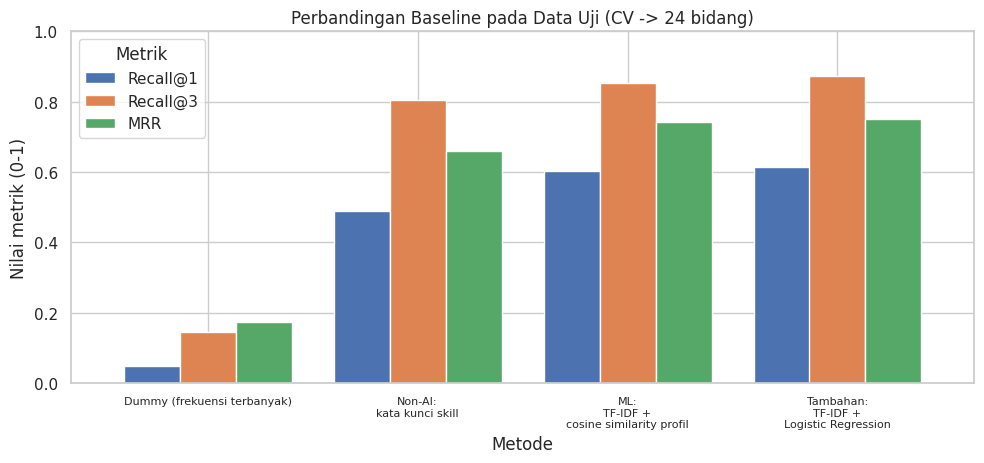

In [15]:
fig, ax = plt.subplots(figsize=(10, 4.8))
tabel[['Recall@1', 'Recall@3', 'MRR']].plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Perbandingan Baseline pada Data Uji (CV -> 24 bidang)')
ax.set_xlabel('Metode')
ax.set_ylabel('Nilai metrik (0-1)')
ax.set_ylim(0, 1)
ax.set_xticklabels([t.get_text().replace(': ', ':\n').replace(' + ', ' +\n') for t in ax.get_xticklabels()], rotation=0, fontsize=8)
ax.legend(title='Metrik')
plt.tight_layout()
plt.show()

### 4h. Validasi Silang 5-Fold pada Data Latih

Satu kali split bisa kebetulan menguntungkan satu metode. Validasi silang di bawah ini mengulang seluruh alur (TF-IDF dan profil dilatih ulang di tiap fold) pada data latih saja, seperti langkah A.9. Data uji tidak disentuh.

In [16]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
Xtr, ytr = X_train.reset_index(drop=True), y_train.reset_index(drop=True)

def cv_metode(nama, fn_skor):
    baris = []
    for tr, va in skf.split(Xtr, ytr):
        skor, kelas = fn_skor(Xtr.iloc[tr], ytr.iloc[tr], Xtr.iloc[va])
        baris.append(metrik(hitung_peringkat(skor, kelas, ytr.iloc[va].values), ytr.iloc[va].values))
    d = pd.DataFrame(baris)
    return {'Recall@1': f'{d["Recall@1"].mean():.3f} ± {d["Recall@1"].std():.3f}',
            'Recall@3': f'{d["Recall@3"].mean():.3f} ± {d["Recall@3"].std():.3f}',
            'MRR': f'{d["MRR"].mean():.3f} ± {d["MRR"].std():.3f}'}

def fn_dummy(Xa, ya, Xb):
    p = Pipeline([('tfidf', buat_tfidf()), ('model', DummyClassifier(strategy='prior'))]).fit(Xa, ya)
    return p.predict_proba(Xb), p.classes_

def fn_kw(Xa, ya, Xb):
    return skor_kata_kunci(Xb.values), KELAS            # tidak ada yang dilatih

def fn_profil(Xa, ya, Xb):
    p = Pipeline([('tfidf', buat_tfidf()), ('profil', ProfilBidang())]).fit(Xa, ya)
    return p.decision_function(Xb), p.named_steps['profil'].classes_

def fn_lr(Xa, ya, Xb):
    p = Pipeline([('tfidf', buat_tfidf()), ('model', LogisticRegression(max_iter=1000))]).fit(Xa, ya)
    return p.predict_proba(Xb), p.classes_

cv_hasil = {'Dummy (frekuensi terbanyak)': cv_metode('dummy', fn_dummy),
            'Non-AI: kata kunci skill': cv_metode('kw', fn_kw),
            'ML: TF-IDF + cosine similarity profil': cv_metode('profil', fn_profil),
            'Tambahan: TF-IDF + Logistic Regression': cv_metode('lr', fn_lr)}
pd.DataFrame(cv_hasil).T

,Recall@1,Recall@3,MRR
Dummy (frekuensi terbanyak),0.047 ± 0.001,0.142 ± 0.002,0.172 ± 0.001
Non-AI: kata kunci skill,0.495 ± 0.024,0.764 ± 0.010,0.647 ± 0.011
ML: TF-IDF + cosine similarity profil,0.588 ± 0.019,0.818 ± 0.021,0.719 ± 0.017
Tambahan: TF-IDF + Logistic Regression,0.611 ± 0.030,0.834 ± 0.020,0.735 ± 0.022


### 4i. Per Bidang: di mana ML dan kata kunci berbeda?

In [17]:
per_kelas = pd.DataFrame({
    'jumlah_CV_uji': y_test.value_counts().sort_index(),
    'Recall@1 kata kunci': [(hitung_peringkat(skor_kw, KELAS, y_test.values)[y_test.values == k] <= 1).mean() for k in KELAS],
    'Recall@1 profil TF-IDF': [(hitung_peringkat(skor_profil, kelas_profil, y_test.values)[y_test.values == k] <= 1).mean() for k in kelas_profil],
}, index=KELAS).round(2)
per_kelas['selisih (ML - kata kunci)'] = (per_kelas['Recall@1 profil TF-IDF'] - per_kelas['Recall@1 kata kunci']).round(2)
print(per_kelas.sort_values('selisih (ML - kata kunci)').to_string())
print('\nBidang ML lebih baik :', (per_kelas['selisih (ML - kata kunci)'] > 0).sum(),
      '| seri:', (per_kelas['selisih (ML - kata kunci)'] == 0).sum(),
      '| kata kunci lebih baik:', (per_kelas['selisih (ML - kata kunci)'] < 0).sum())

                        jumlah_CV_uji  Recall@1 kata kunci  Recall@1 profil TF-IDF  selisih (ML - kata kunci)
ACCOUNTANT                         24                 0.92                    0.79                      -0.13
SALES                              23                 0.70                    0.57                      -0.13
INFORMATION-TECHNOLOGY             24                 0.96                    0.83                      -0.13
TEACHER                            20                 0.80                    0.75                      -0.05
HR                                 22                 0.95                    0.91                      -0.04
CHEF                               24                 0.71                    0.67                      -0.04
HEALTHCARE                         23                 0.65                    0.61                      -0.04
BPO                                 4                 0.00                    0.00                       0.00
ENGINEERIN

**Apakah baseline ML sudah lebih baik daripada baseline non-AI? Jelaskan.**

**Ya, pada data ini baseline ML lebih baik daripada baseline non-AI, tetapi keunggulannya tidak merata.**

- **Pada data uji**, profil TF-IDF + cosine similarity unggul di semua metrik: Recall@1 0,604 vs 0,489, Recall@3 0,853 vs 0,805, MRR 0,742 vs 0,660, dan Macro Recall@1 0,578 vs 0,451. Keduanya jauh di atas dummy (Recall@1 0,048, MRR 0,174), jadi kedua metode memang menangkap sinyal bidang.
- **Hasilnya bukan kebetulan satu kali split.** Pada validasi silang 5-fold di data latih, pola yang sama muncul: Recall@1 0,588 ± 0,019 vs 0,495 ± 0,024, Recall@3 0,818 ± 0,021 vs 0,764 ± 0,010, MRR 0,719 ± 0,017 vs 0,647 ± 0,011. Selisihnya lebih besar daripada simpangan masing-masing metode.
- **Keunggulan ML paling besar pada bidang yang kosakatanya sulit ditebak manual.** ML lebih baik di 16 dari 24 bidang. Contohnya BUSINESS-DEVELOPMENT (Recall@1 0,08 menjadi 0,79), AUTOMOBILE (0,00 menjadi 0,57, tetapi hanya 7 CV uji), ARTS (0,00 menjadi 0,29), dan ADVOCATE (0,17 menjadi 0,46). Profil TF-IDF belajar kata pembeda dari CV nyata, sedangkan kamus manual hanya sebaik tebakan penulisnya.
- **Kata kunci masih menang di bidang dengan kosakata khas dan jelas**: INFORMATION-TECHNOLOGY (0,96 vs 0,83), ACCOUNTANT (0,92 vs 0,79), HR (0,95 vs 0,91), serta SALES, TEACHER, CHEF, dan HEALTHCARE. Di bidang seperti ini kamus manual sudah tepat sasaran.
- **Logistic Regression** sedikit lebih tinggi pada Recall@3 dan MRR (0,873 dan 0,750), tetapi Macro Recall@1-nya lebih rendah (0,563 vs 0,578) dan selisihnya masih dalam rentang simpangan validasi silang. Jadi tidak ada alasan kuat untuk memilih model yang lebih rumit sebelum ada data nyata; profil cosine sesuai Tabel Panduan dan mudah dijelaskan.

**Catatan kehati-hatian.** Recall@1 ML hanya sekitar 60%, sehingga sistem sebaiknya menampilkan top-3 (Recall@3 sekitar 85%) dan tetap memakai penilaian manusia. BPO (22 CV, hanya 4 CV uji) gagal total pada kedua metode, dan angkanya terlalu sedikit untuk disimpulkan. Terakhir, label `Category` hanyalah proksi bidang proyek dan CV-nya bukan CV mahasiswa Indonesia, sehingga hasil ini belum membuktikan performa pada data ProjectMatch AI yang sebenarnya.

---
## Soal 5 — Pemeriksaan Data Leakage

### 5a. Daftar fitur dan status ketersediaan saat prediksi

In [18]:
daftar = pd.DataFrame([
    ['teks_penuh (dari Resume_str)', 'Input model (TF-IDF)', 'Ya', 'Tersedia saat CV diunggah. Sudah dimasking dan dibersihkan.'],
    ['judul_cv (nama jabatan di awal CV)', 'Bagian dari teks_penuh', 'Ya, tapi RISIKO', 'Dekat dengan label bidang. Diuji sensitivitasnya di 5d.'],
    ['jumlah_kata, jumlah_bagian_cv, tahun_pengalaman_klaim, jumlah_skill_teknis', 'Tidak dipakai model baseline', 'Ya', 'Dihitung dari teks CV sendiri, tanpa label. Disiapkan untuk eksperimen berikutnya.'],
    ['Category', 'Label / kunci jawaban', 'Bukan fitur', 'Hanya dipakai untuk membangun profil dari data latih dan menghitung metrik.'],
    ['ID', 'Pengenal', 'Tidak dipakai', 'Tidak membawa makna bidang.'],
    ['Resume_html', 'Tidak dibaca', 'Tidak dipakai', 'Versi HTML dari teks yang sama, jadi redundan.'],
], columns=['Fitur / kolom', 'Peran', 'Diketahui sebelum hasil?', 'Catatan'])
pd.set_option('display.max_colwidth', 90)
daftar

,Fitur / kolom,Peran,Diketahui sebelum hasil?,Catatan
0,teks_penuh (dari Resume_str),Input model (TF-IDF),Ya,Tersedia saat CV diunggah. Sudah dimasking dan dibersihkan.
1,judul_cv (nama jabatan di awal CV),Bagian dari teks_penuh,"Ya, tapi RISIKO",Dekat dengan label bidang. Diuji sensitivitasnya di 5d.
2,"jumlah_kata, jumlah_bagian_cv, tahun_pengalaman_klaim, jumlah_skill_teknis",Tidak dipakai model baseline,Ya,"Dihitung dari teks CV sendiri, tanpa label. Disiapkan untuk eksperimen berikutnya."
3,Category,Label / kunci jawaban,Bukan fitur,Hanya dipakai untuk membangun profil dari data latih dan menghitung metrik.
4,ID,Pengenal,Tidak dipakai,Tidak membawa makna bidang.
5,Resume_html,Tidak dibaca,Tidak dipakai,"Versi HTML dari teks yang sama, jadi redundan."


Tidak ada fitur yang jelas baru diketahui **setelah** hasil pencocokan terjadi (misalnya status diterima atau tidaknya kandidat). Satu-satunya fitur berisiko adalah **judul CV**: ia tersedia saat prediksi, tetapi nama jabatannya sangat dekat dengan label. Diuji pada 5d.

### 5b. Preprocessing berada di dalam Pipeline setelah split?

In [19]:
print('Langkah Pipeline ML:', [n for n, _ in pipe_profil.steps])
print('Kosakata TF-IDF dibangun dari', len(X_train), 'CV latih (bukan dari', len(X), 'CV total).')

# Uji kontaminasi: TF-IDF di-fit pada SELURUH data (salah) vs hanya data latih (benar)
tfidf_bocor = buat_tfidf().fit(X)
profil_bocor = ProfilBidang().fit(tfidf_bocor.transform(X_train), y_train.values)
skor_bocor = profil_bocor.decision_function(tfidf_bocor.transform(X_test))
m_bocor = metrik(hitung_peringkat(skor_bocor, profil_bocor.classes_, y_test.values), y_test.values)
m_benar = hasil['ML: TF-IDF + cosine similarity profil']

print(f'\n{"":<34}{"Recall@1":>10}{"Recall@3":>10}{"MRR":>8}')
print(f'{"TF-IDF fit pada semua data (SALAH)":<34}{m_bocor["Recall@1"]:>10.3f}{m_bocor["Recall@3"]:>10.3f}{m_bocor["MRR"]:>8.3f}')
print(f'{"TF-IDF fit pada data latih (BENAR)":<34}{m_benar["Recall@1"]:>10.3f}{m_benar["Recall@3"]:>10.3f}{m_benar["MRR"]:>8.3f}')

Langkah Pipeline ML: ['tfidf', 'profil']
Kosakata TF-IDF dibangun dari 1984 CV latih (bukan dari 2481 CV total).



                                    Recall@1  Recall@3     MRR
TF-IDF fit pada semua data (SALAH)     0.604     0.853   0.742
TF-IDF fit pada data latih (BENAR)     0.604     0.853   0.742


### 5c. Objek yang sama di data latih dan data uji?

In [20]:
# (1) ID yang sama
id_latih = set(df_bersih.loc[X_train.index, 'ID'])
id_uji = set(df_bersih.loc[X_test.index, 'ID'])
print('ID yang muncul di latih dan uji sekaligus :', len(id_latih & id_uji))

# (2) Teks yang sama persis
print('Teks sama persis di latih dan uji          :', len(set(X_train) & set(X_test)))

# (3) Hampir sama: cosine similarity tertinggi tiap CV uji terhadap seluruh CV latih
vec = buat_tfidf().fit(X_train)
S = (vec.transform(X_test) @ vec.transform(X_train).T).toarray()
maks = S.max(axis=1)
tetangga = S.argmax(axis=1)
print('CV uji dengan kemiripan > 0.90 ke suatu CV latih :', (maks > 0.90).sum(), 'dari', len(maks))
print('CV uji dengan kemiripan > 0.80 ke suatu CV latih :', (maks > 0.80).sum())

mirip = np.where(maks > 0.90)[0]
y_tr_arr, y_te_arr = y_train.values, y_test.values
pd.DataFrame({'kemiripan': maks[mirip].round(3),
              'bidang CV uji': y_te_arr[mirip],
              'bidang tetangga di latih': y_tr_arr[tetangga[mirip]]})

ID yang muncul di latih dan uji sekaligus : 0
Teks sama persis di latih dan uji          : 0


CV uji dengan kemiripan > 0.90 ke suatu CV latih : 3 dari 497
CV uji dengan kemiripan > 0.80 ke suatu CV latih : 4


,kemiripan,bidang CV uji,bidang tetangga di latih
0,0.999,SALES,SALES
1,0.949,HR,HR
2,0.976,AGRICULTURE,AGRICULTURE


In [21]:
# Perbaikan: keluarkan CV uji yang hampir identik dengan CV latih, lalu hitung ulang metrik
aman = maks <= 0.90
peringkat_aman = hitung_peringkat(skor_profil[aman], kelas_profil, y_test.values[aman])
m_aman = metrik(peringkat_aman, y_test.values[aman])
print(f'CV uji sesudah dikeluarkan: {aman.sum()} (dikeluarkan {(~aman).sum()})')
print(f'{"":<28}{"Recall@1":>10}{"Recall@3":>10}{"MRR":>8}')
print(f'{"Data uji penuh":<28}{m_benar["Recall@1"]:>10.3f}{m_benar["Recall@3"]:>10.3f}{m_benar["MRR"]:>8.3f}')
print(f'{"Tanpa CV hampir-duplikat":<28}{m_aman["Recall@1"]:>10.3f}{m_aman["Recall@3"]:>10.3f}{m_aman["MRR"]:>8.3f}')

CV uji sesudah dikeluarkan: 494 (dikeluarkan 3)
                              Recall@1  Recall@3     MRR
Data uji penuh                   0.604     0.853   0.742
Tanpa CV hampir-duplikat         0.601     0.852   0.741


### 5d. Uji sensitivitas: apakah judul CV membocorkan label?
Seluruh evaluasi diulang memakai `teks_tanpa_header` (judul CV dibuang) dengan split yang sama.

In [22]:
Xh = df_bersih['teks_tanpa_header']
Xh_train, Xh_test = Xh.loc[X_train.index], Xh.loc[X_test.index]

pipe_profil_h = Pipeline([('tfidf', buat_tfidf()), ('profil', ProfilBidang())]).fit(Xh_train, y_train)
pipe_lr_h = Pipeline([('tfidf', buat_tfidf()), ('model', LogisticRegression(max_iter=1000))]).fit(Xh_train, y_train)

tanpa = {
    'Non-AI: kata kunci skill': metrik(hitung_peringkat(skor_kata_kunci(Xh_test.values), KELAS, y_test.values), y_test.values),
    'ML: TF-IDF + cosine similarity profil': metrik(hitung_peringkat(pipe_profil_h.decision_function(Xh_test), pipe_profil_h.named_steps['profil'].classes_, y_test.values), y_test.values),
    'Tambahan: TF-IDF + Logistic Regression': metrik(hitung_peringkat(pipe_lr_h.predict_proba(Xh_test), pipe_lr_h.classes_, y_test.values), y_test.values),
}
banding = pd.DataFrame({
    'Recall@3 (teks penuh)': {k: hasil[k]['Recall@3'] for k in tanpa},
    'Recall@3 (tanpa judul)': {k: tanpa[k]['Recall@3'] for k in tanpa},
    'MRR (teks penuh)': {k: hasil[k]['MRR'] for k in tanpa},
    'MRR (tanpa judul)': {k: tanpa[k]['MRR'] for k in tanpa},
}).round(3)
banding['selisih MRR'] = (banding['MRR (tanpa judul)'] - banding['MRR (teks penuh)']).round(3)
banding

,Recall@3 (teks penuh),Recall@3 (tanpa judul),MRR (teks penuh),MRR (tanpa judul),selisih MRR
Non-AI: kata kunci skill,0.805,0.789,0.660,0.654,-0.006
ML: TF-IDF + cosine similarity profil,0.853,0.831,0.742,0.728,-0.014
Tambahan: TF-IDF + Logistic Regression,0.873,0.855,0.750,0.740,-0.010


### Hasil pemeriksaan data leakage dan perbaikannya

**a. Fitur yang dipakai.** Model baseline hanya memakai satu input, yaitu `teks_penuh` (teks CV yang sudah dibersihkan). Tidak ada fitur yang baru diketahui setelah hasil pencocokan terjadi (misalnya status kandidat diterima atau tidak). `Category` hanya menjadi label, sedangkan `ID` dan `Resume_html` tidak dipakai. Satu-satunya bagian berisiko adalah **judul CV**: tersedia saat prediksi, tetapi nama jabatannya dekat dengan label, sehingga diuji pada poin (d).

**b. Preprocessing di dalam Pipeline setelah split.** Data dipisah lebih dulu (1.984 latih, 497 uji), lalu `TfidfVectorizer` dan `ProfilBidang` berada di dalam `Pipeline` dan hanya di-*fit* pada CV latih. Sebagai uji, TF-IDF juga di-*fit* pada seluruh data (cara yang salah): hasilnya identik sampai tiga desimal (Recall@1 0,604, Recall@3 0,853, MRR 0,742). Artinya pada data ini kontaminasi tidak mengubah angka karena TF-IDF tidak memakai label, tetapi alur yang benar tetap dipertahankan agar tidak menimbulkan masalah pada data lain atau data yang lebih kecil.

**c. Objek yang sama di data latih dan uji.** Tidak ada `ID` maupun teks yang sama persis di kedua bagian (dua pasang duplikat sudah dibuang sebelum split pada Soal 3). Namun ada **3 dari 497 CV uji yang hampir identik** dengan CV latih (kemiripan 0,999, 0,976, dan 0,949), semuanya dengan bidang yang sama. Setelah ketiganya dikeluarkan dari data uji, metrik nyaris tidak berubah (Recall@1 0,604 menjadi 0,601, Recall@3 0,853 menjadi 0,852, MRR 0,742 menjadi 0,741), jadi dampaknya sangat kecil. **Perbaikan untuk pipeline final:** buang CV hampir-duplikat (cosine similarity > 0,9) sebelum split. Dataset ini tidak punya identitas penulis, jadi tidak bisa dipastikan apakah CV berbeda berasal dari orang yang sama. Pada data mahasiswa asli, split sebaiknya dilakukan **per mahasiswa**.

**d. Uji sensitivitas judul CV.** Setelah judul dibuang, Recall@3 turun 0,016–0,022 dan MRR turun 0,006–0,014 pada ketiga metode, dan urutan metode tidak berubah (ML tetap di atas kata kunci: Recall@3 0,831 vs 0,789, MRR 0,728 vs 0,654). Jadi judul membantu sedikit, tetapi skor tidak bergantung padanya.

**Kesimpulan.** Tidak ditemukan kebocoran yang material. Skor sedang (Recall@1 sekitar 60%) juga bukan "terlalu bagus" seperti pada simulasi A.10. Satu hal yang tidak bisa diperiksa dari data ini: asal label `Category` tidak didokumentasikan di dataset. Jika label berasal dari kategori tempat CV dikumpulkan, mungkin ada pola template per kategori yang membantu model tanpa mencerminkan kemampuan kandidat.

---
## Menyimpan Data Bersih

In [23]:
Path('../data/processed').mkdir(parents=True, exist_ok=True)
kolom_simpan = ['ID', 'Category', 'teks_penuh', 'teks_tanpa_header', 'judul_cv'] + fitur_baru
df_bersih[kolom_simpan].to_csv('../data/processed/resume_bersih.csv', index=False)
print('Tersimpan: data/processed/resume_bersih.csv', df_bersih[kolom_simpan].shape)
print('Tersimpan: results/perbandingan_baseline.csv')

Tersimpan: data/processed/resume_bersih.csv (2481, 9)
Tersimpan: results/perbandingan_baseline.csv
